In [2]:
!pip install pandas numpy matplotlib statsmodels requests

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [4]:
df_A = pd.read_csv("data/SPY.csv")
df_B = pd.read_csv("data/QQQ.csv")

In [10]:
df_A.head()

,timestamp,open,high,low,close,volume
0,2022-09-30 04:00:00,366.02,366.13,366.02,366.08,8354
1,2022-09-30 04:01:00,366.11,366.13,366.07,366.13,1100
2,2022-09-30 04:02:00,365.98,365.98,365.87,365.91,600
3,2022-09-30 04:03:00,365.98,366.06,365.87,366.06,1800
4,2022-09-30 04:04:00,366.07,366.07,366.02,366.02,223


In [12]:
df_B.head()

,timestamp,open,high,low,close,volume
0,2022-09-30 04:00:00,274.00,274.84,274.00,274.65,5209
1,2022-09-30 04:01:00,274.70,274.73,274.63,274.68,12542
2,2022-09-30 04:02:00,274.61,274.61,274.48,274.50,7092
3,2022-09-30 04:03:00,274.47,274.52,274.42,274.47,9774
4,2022-09-30 04:04:00,274.55,274.61,274.55,274.55,500


In [14]:
# redefine column names
df_A.columns = ["datetime","open","high","low","close","volume"]
df_B.columns = ["datetime","open","high","low","close","volume"]

In [16]:
df_A["datetime"] = pd.to_datetime(df_A["datetime"])
df_B["datetime"] = pd.to_datetime(df_B["datetime"])

df_A.set_index("datetime", inplace=True)
df_B.set_index("datetime", inplace=True)

df_A = df_A.sort_index()
df_B = df_B.sort_index()

In [18]:
df = pd.DataFrame({
    "A_close": df_A["close"],
    "B_close": df_B["close"]
})

df = df.dropna()

In [24]:
df.shape
df.head()

,A_close,B_close
datetime,,
2022-09-30 04:00:00,366.08,274.65
2022-09-30 04:01:00,366.13,274.68
2022-09-30 04:02:00,365.91,274.50
2022-09-30 04:03:00,366.06,274.47
2022-09-30 04:04:00,366.02,274.55


In [26]:
# intraday is noisy when market open and when it closes.
# market open (9:30 - 9:45)
# market close (3:45 - 4:00)

df = df.between_time("09:45", "15:45")

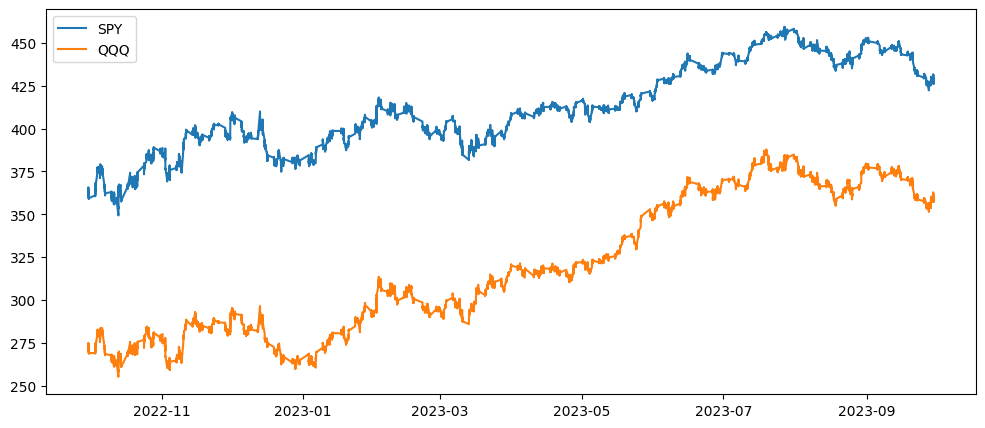

In [28]:
plt.figure(figsize=(12,5))
plt.plot(df["A_close"], label="SPY")
plt.plot(df["B_close"], label="QQQ")
plt.legend()
plt.show()

## Estimate Hedge Ratio (OLS Regression)

In [51]:
import statsmodels.api as sm

# use log prices to stabilize variance and improve robustness.
X = sm.add_constant(df["B_close"])
model = sm.OLS(df["A_close"], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                A_close   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                 1.237e+06
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:00:21   Log-Likelihood:            -2.9898e+05
No. Observations:               90406   AIC:                         5.980e+05
Df Residuals:                   90404   BIC:                         5.980e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        212.6690      0.180   1179.556      0.0

Above plot provides some useful infromation, such as Beta, R-squared, statistical significance. 

In [54]:
beta = model.params["B_close"]

df["spread"] = df["A_close"] - beta * df["B_close"]

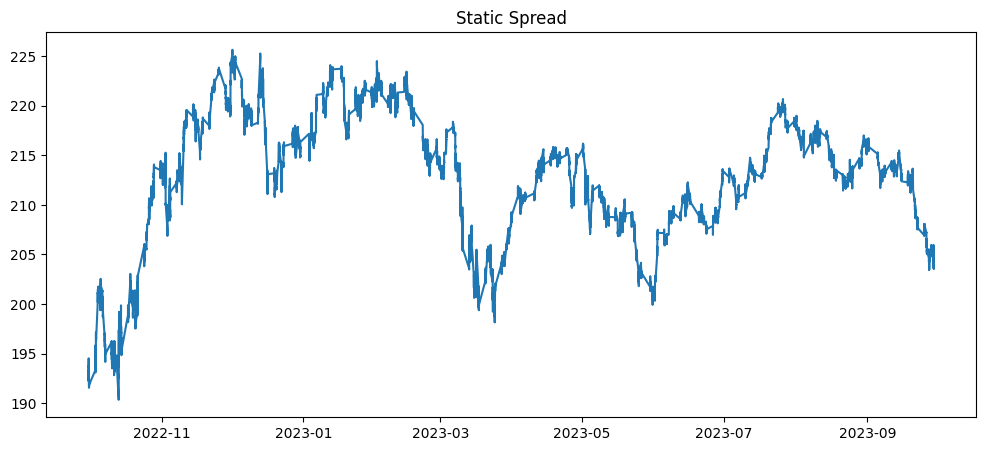

In [56]:
plt.figure(figsize=(12,5))
plt.plot(df["spread"])
plt.title("Static Spread")
plt.show()

The static plot shows that there is oscillatory behavior because we see multiple cycles. 
It's not strictly stationary. 
Mean seems to drift over months. 


In [39]:
# 1. since we are using 1-minute data and there are 5 trading days each week, the rolling window is 1950
window = 390  # 1 day for 1-minute data


We can have rolling window of 2-5 trading days. 
We don't want to have too short rolling window because hedge ratio becomes unstable and it contains too mcuh noisy beta estimates.
we don't want it too long neither because relationship may drift slow adaptation.



In [262]:
# 1. Compute Rolling Hedge Ratio

rolling_cov = df["A_close"].rolling(window).cov(df["B_close"])
rolling_var = df["B_close"].rolling(window).var()

df["beta_roll"] = rolling_cov / rolling_var

In [264]:
# 2. construct dynamic spread
df["spread_roll"] = df["A_close"] - df["beta_roll"] * df["B_close"]

In [266]:
# 3. compute rolling z-socre
df["spread_mean"] = df["spread_roll"].rolling(window).mean()
df["spread_std"] = df["spread_roll"].rolling(window).std()

df["zscore"] = (df["spread_roll"] - df["spread_mean"]) / df["spread_std"]

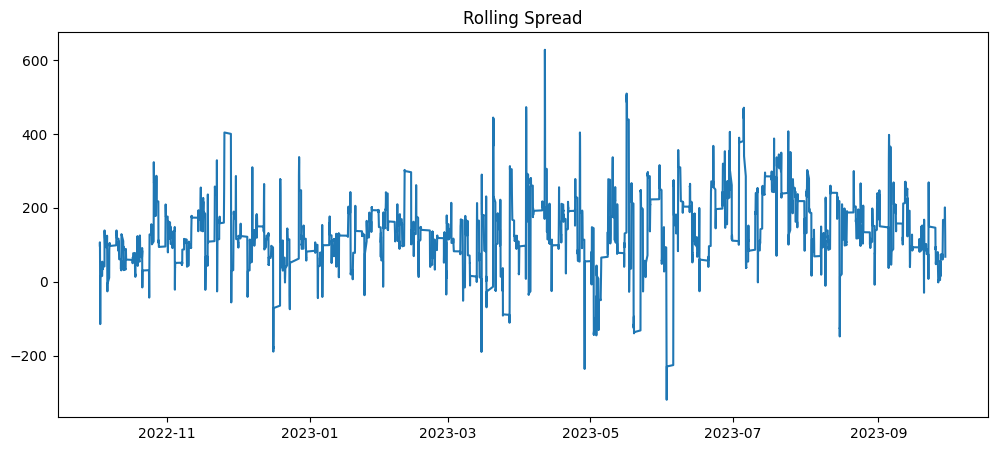

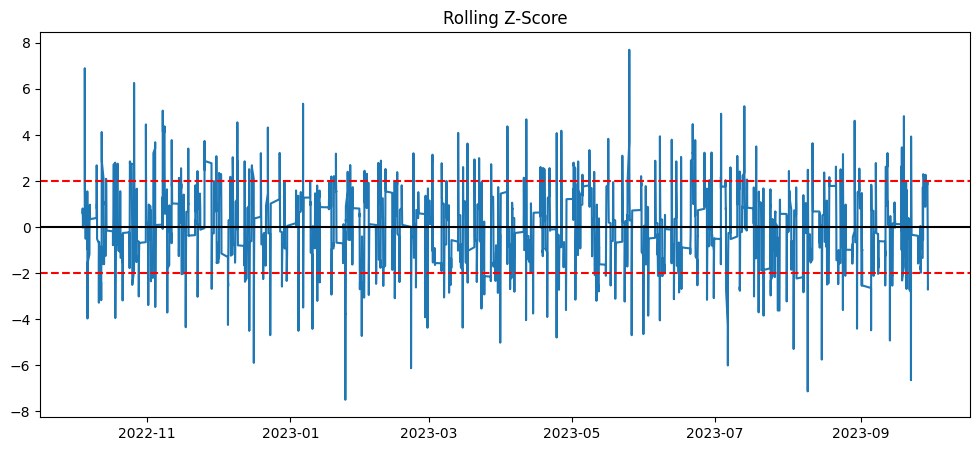

In [268]:
# 4. plot rolling spread and z_score
plt.figure(figsize=(12,5))
plt.plot(df["spread_roll"])
plt.title("Rolling Spread")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df["zscore"])
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='red', linestyle='--')
plt.axhline(0, color='black')
plt.title("Rolling Z-Score")
plt.show()

Z-Score spikes those above 2 or below -2 are trading opprtunities

In [271]:
# 5. generate trading signals, trading raw signal

df["position_raw"] = 0
df.loc[df["zscore"] < -2.5, "position_raw"] = 1
df.loc[df["zscore"] > 2.5, "position_raw"] = -1

df["position_raw"] = df["position_raw"].replace(0, np.nan).ffill()
df.loc[df["zscore"] * df["zscore"].shift(1) < 0, "position_raw"] = 0
df["position_raw"] = df["position_raw"].ffill().fillna(0)

In [273]:
# minimum holding period
min_hold = 30  # 30 bars (30 minutes if 1-min data)

df["position"] = df["position_raw"].copy()

last_change_index = 0
current_position = 0

for i in range(1, len(df)):
    if df["position"].iloc[i] != current_position:
        # If trying to change position
        if i - last_change_index < min_hold:
            df["position"].iloc[i] = current_position
        else:
            current_position = df["position"].iloc[i]
            last_change_index = i

In [275]:
# 6. compute strategy return
df["ret_A"] = df["A_close"].pct_change()
df["ret_B"] = df["B_close"].pct_change()



df["strategy_ret"] = (
    df["position"].shift(1) *
    (df["ret_A"] - df["beta_roll"] * df["ret_B"])
)

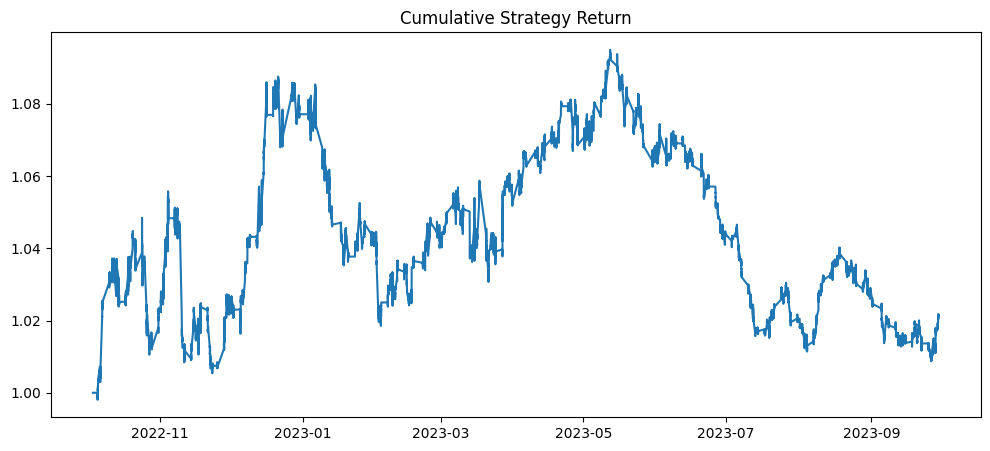

In [277]:
# 7. evalute performance
df["cum_ret"] = (1 + df["strategy_ret"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(df["cum_ret"])
plt.title("Cumulative Strategy Return")
plt.show()

## Next, Transaction Cost

In [281]:
df["turnover"] = df["position"].diff().abs()


In [283]:
# assume 0.0004 per transaction cost
cost_per_trade = 0.0004

df["cost"] = df["turnover"] * cost_per_trade
df["strategy_ret_net"] = df["strategy_ret"] - df["cost"]

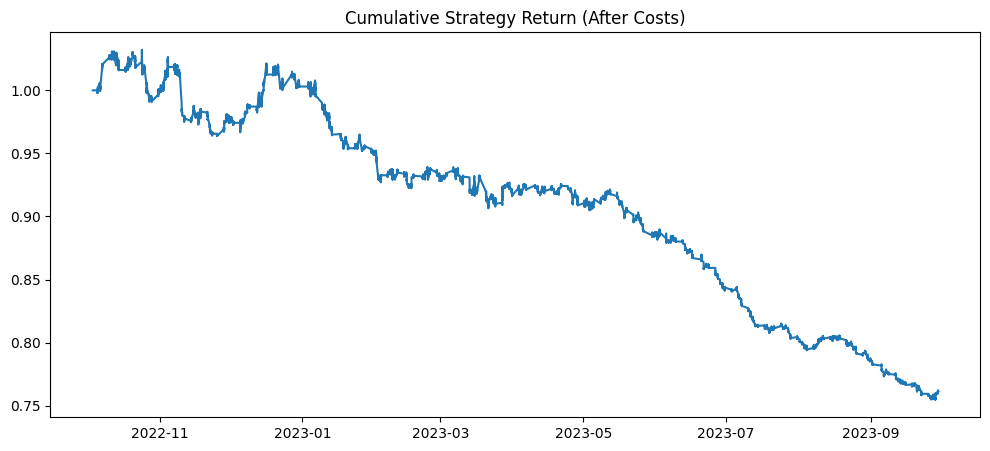

In [285]:
# plot return after including transaction cost
df["cum_ret_net"] = (1 + df["strategy_ret_net"]).cumprod()

plt.figure(figsize=(12,5))
plt.plot(df["cum_ret_net"])
plt.title("Cumulative Strategy Return (After Costs)")
plt.show()

## Performance Metrics

In [289]:
import numpy as np
# there are 252 trading days
annual_factor = np.sqrt(252 * 390)

sharpe = annual_factor * df["strategy_ret_net"].mean() / df["strategy_ret_net"].std()

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: -3.2288759749714973


In [291]:
cum = df["cum_ret_net"]
rolling_max = cum.cummax()
drawdown = cum / rolling_max - 1
max_dd = drawdown.min()

print("Max Drawdown:", max_dd)

Max Drawdown: -0.26890618643701847


In [293]:
total_return = df["cum_ret_net"].iloc[-1] - 1
print("Total Return:", total_return)

Total Return: -0.23882751552670656


### Based on above statistics, the model performance is poor and seems like it's cause by having too much turnover. 

In [297]:
df["turnover"].sum()

735.0

In [299]:
# annualized turnover
bars_per_year = 252 * 390
annual_turnover = df["turnover"].sum() / len(df) * bars_per_year
print("Annual Turnover:", annual_turnover)

Annual Turnover: 799.0155520651284


# what else we can do for this pair trading system:
    1. Even Better: Make It Stronger Before Putting It On Resume
    2. You can improve it further by:
    3. Adding robustness analysis (parameter sensitivity heatmap)
    4. Showing cost vs Sharpe curve
    5. Showing turnover vs threshold curve
    6. Comparing 1-min vs 5-min performance
    7. Showing how Sharpe decays with cost assumption
    8. Then your project becomes:
    9. A study of intraday stat-arb robustness.
    10. That’s impressive.